In [1]:
import numpy as np
import matplotlib.pyplot as plt

## MODEL

In [2]:
import tensorflow as tf

def contraction(inputs,num_filters,dropout_rate=0.1):
    c = tf.keras.layers.Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(inputs)
    c = tf.keras.layers.Dropout(dropout_rate)(c)
    c = tf.keras.layers.Conv2D(num_filters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c)
    b = tf.keras.layers.BatchNormalization()(c)
    r = tf.keras.layers.ReLU()(b)
    p = tf.keras.layers.MaxPooling2D((2, 2))(r)
    return c,p

def expansion(inputs,skip_features,num_filters,dropout_rate=0.1):
    u = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides=(2, 2), padding='same')(inputs)
    u = tf.keras.layers.concatenate([u, skip_features])
    u = tf.keras.layers.BatchNormalization()(u)
    u = tf.keras.layers.ReLU()(u)
    return u

def unet(input_shape,num_classes=1,nfilters=256,dropout_rate=0.1):
    inputs = tf.keras.layers.Input(input_shape)
    #Contraction path
    c1,p1=contraction(inputs,nfilters/16)
    c2,p2=contraction(p1,nfilters/8)
    c3,p3=contraction(p2,nfilters/4)
    c4,p4=contraction(p3,nfilters/2)
    #bottleneck
    c5 = tf.keras.layers.Conv2D(nfilters, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    b5 = tf.keras.layers.BatchNormalization()(c5)
    r5 = tf.keras.layers.ReLU()(b5)
    c5 = tf.keras.layers.Dropout(0.3)(r5)
    c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    #Expansive path 
    u6=expansion(c5,c4,nfilters/2)
    u7=expansion(u6,c3,nfilters/4)
    u8=expansion(u7,c2,nfilters/8)
    u9=expansion(u8,c1,nfilters/16)
    outputs = tf.keras.layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(u9)

    model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
    return model

In [3]:
model = unet((288,576,1),nfilters=128)
model.summary()



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 288, 576, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 288, 576, 8)          80        ['input_1[0][0]']             
                                                                                                  
 dropout (Dropout)           (None, 288, 576, 8)          0         ['conv2d[0][0]']              
                                                                                                  
 conv2d_1 (Conv2D)           (None, 288, 576, 8)          584       ['dropout[0][0]']             
                                                                                            

## DATA PROCESSING

In [4]:
from PIL import Image,ImageEnhance,ImageFilter
from os import listdir
#load backgrounds
backgrounds=[]
for dir in listdir('../imgs/blockstorm/background'):
    backgrounds.append(Image.open('../imgs/blockstorm/background/'+dir).resize((576,288)))
#load characters
chars=[]
for dir in listdir('../imgs/blockstorm/character'):
    char=Image.open('../imgs/blockstorm/character/'+dir)
    #create different color characters
    r, g, b,a = char.split()
    b_half = b.point(lambda x: int(x * 0.5))
    chars.append(char)
    char = Image.merge("RGBA", (r,b,b,a))
    chars.append(char)
    char = Image.merge("RGBA", (r,g,g,a))
    chars.append(char)
    char = Image.merge("RGBA", (b,b,r,a))
    chars.append(char)
    char = Image.merge("RGBA", (b,b,g,a))
    chars.append(char)
#load objects
objects=[]
for dir in listdir('../imgs/blockstorm/object'):
    objects.append(Image.open('../imgs/blockstorm/object/'+dir))

ui=Image.open('../imgs/blockstorm/ui.png').resize((324,182))
validset=[]
for dir in listdir('../imgs/blockstorm/validation'):
    validset.append(Image.open('../imgs/blockstorm/validation/'+dir))

In [5]:
#class that procedurally generates new images starting from base backgrounds, chars, objects
class ImageGenerator:
    def __init__(self,backgrounds, characters, objects,ui):
        self.backgrounds=backgrounds
        self.characters=characters
        self.objects=objects
        self.ui=ui
    
    #merge background with another image (char/ui/object)
    def merger(self,background,masked,topaste,x,y,block=False):
        background.paste(topaste, (x, y), mask=topaste.getchannel(3)) 
        #mask
        masked_paste=topaste.getchannel(3)
        if block:
            masked.paste(0, (x, y), mask=masked_paste)
        else:
            masked_paste = masked_paste.point([0] + [255]*255)
            masked.paste(masked_paste,(x,y),mask=masked_paste)
    
    #char_p: probability of character not appearing
    def new_image(self,char_p=0.1,object_p=0.6,bg_p=0.7,augmentation=True):
        #get random background
        idxbg=np.random.randint(0,len(backgrounds))
        background=backgrounds[idxbg].copy()
        img=background.convert('RGBA')

        #masked image
        masked=Image.new('L',img.size)

        #with probability 1-p, insert character
        if np.random.uniform()>char_p:
            idxchar=np.random.randint(0,len(chars))
            char=chars[idxchar].copy()
            offx=np.random.randint(-30,460)
            offy=np.random.randint(-30,160)
            #augmentation
            #scaling factor
            factor=np.random.uniform(0.3,1.5)
            h,w=char.size
            char=char.resize((int(h*factor),int(w*factor)))
            if augmentation:
                char=self.transform(char)
            self.merger(img,masked,char,offx,offy)
            
        
        #insert object with probability 1-p
        if np.random.uniform()>object_p:
            offx=np.random.randint(-30,460)
            offy=np.random.randint(-30,160)
            factor=np.random.uniform(0.2,0.4)
            idobj=np.random.randint(low=0,high=len(objects))
            obj=objects[idobj]
            h,w=obj.size
            obj=obj.resize((int(h*factor),int(w*factor)))
            self.merger(img,masked,obj,offx,offy,True)

        if augmentation:
            #flip entire image with probability 1-p
            if np.random.uniform()>bg_p:
                img=img.transpose(Image.FLIP_LEFT_RIGHT)
                masked=masked.transpose(Image.FLIP_LEFT_RIGHT)
            elif np.random.uniform()>bg_p:
                img=img.transpose(Image.FLIP_TOP_BOTTOM)
                masked=masked.transpose(Image.FLIP_TOP_BOTTOM)
    
        return img,masked
    
    def transform(self,img,p=0.4):
        #quad
        if np.random.uniform()>p:
            quad = [0, 0, 0, 256,256, 512, 128, -256]
            img=img.transform((256, 256), Image.Transform.QUAD, data=quad)

        #rotate
        if np.random.uniform()>p:
            angle = np.random.randint(20, 46) if np.random.rand() < 0.5 else np.random.randint(-45, -19)
            img = img.rotate(angle,center=(75, 75),expand=True)

        #color jitter
        if np.random.uniform()>p:
            brightness=0.4
            img = ImageEnhance.Brightness(img).enhance(1.0 + np.random.uniform(-brightness, brightness))
            contrast=0.4
            img = ImageEnhance.Contrast(img).enhance(1 + np.random.uniform(-contrast, contrast))
            saturation=0.4
            img = ImageEnhance.Color(img).enhance(1 + np.random.uniform(-saturation, saturation))
        
        #blur
        if np.random.uniform()>p:
            r = np.random.uniform(0, 1)
            img=img.filter(ImageFilter.GaussianBlur(r))

        #opacity 
        if np.random.uniform()>p:
            alpha = img.split()[-1]
            factor = np.random.uniform(0.7, 0.9)
            alpha = alpha.point(lambda p: int(p * factor))
            img.putalpha(alpha)
        return img

In [6]:
def predict(model,img,scale=255):
    predicted=model.predict(np.array(img)[None,...]/scale)[0]
    argpred=np.argmax(predicted,axis=2)
    return argpred
def alt_predict(model,img,scale=255,thresh=0.5):
    predicted=model.predict(np.array(img)[None,...]/scale)[0,...,0]
    argpred=(predicted>thresh).astype(np.uint8)
    return argpred

In [7]:
def display_segmented(img):
    rgb=np.zeros((*img.shape,3))
    rgb[img==0,0]=1
    rgb[img==1,1]=1
    rgb[img==2,2]=1
    plt.imshow(rgb)
    plt.axis('off')

def display_transp_segmented(img,mask):
    img = np.array(img)[...,:3]
    predicted_mask = mask
    color_mask = np.zeros_like(img)
    color_mask[predicted_mask == 1] = [255, 0, 0]
    # Transparency factor
    alpha = 0.5  
    blended_image = img * (1 - alpha) + color_mask * alpha
    blended_image = blended_image.astype(np.uint8)

    plt.figure(figsize=(10, 10))
    plt.imshow(blended_image)
    plt.axis('off')
    plt.show()

def disp_click(img,mask,x,y):
    img=img.convert('RGB')
    img = np.array(img)[...,:3]
    predicted_mask = mask
    color_mask = np.zeros_like(img)
    color_mask[predicted_mask == 1] = [255, 0, 0]
    # Transparency factor
    alpha = 0.5  
    blended_image = img * (1 - alpha) + color_mask * alpha
    blended_image = blended_image.astype(np.uint8)

    plt.figure(figsize=(10, 10))
    plt.imshow(blended_image)
    plt.plot(y,x,'x',markersize=10)
    plt.axis('off')
    plt.show()

def getcentroid(mask):
    mask=np.array(mask)
    mask=np.column_stack(np.where(mask==1))
    if mask.size==0:
        return 0,0
    maxy,miny=np.max(mask[:,0]),np.min(mask[:,0])
    h=miny+(maxy-miny)/3
    mask=mask[mask[:,0]<h]
    centroid=mask.mean(axis=0).astype(int)
    return centroid

In [8]:
def catch_movement(oldimg,newimg,thresh=0.1):
    oldimg=np.array(oldimg)
    newimg=np.array(newimg)
    img=np.abs(newimg-oldimg)
    img=(img>thresh).astype(int)
    return img

from scipy import ndimage

def clean_segmentation_mask(
    mask: np.ndarray,
    keep_mode: str = "largest",
    min_relative_size: float = 0.2,
    apply_opening: bool = True,
) -> np.ndarray:
    """
    Clean a binary segmentation mask by removing small spurious regions.

    Parameters
    ----------
    mask : np.ndarray
        2D binary array (0/1 or bool).
    keep_mode : str
        "largest" → keep only the largest component (default, safest)
        "relative" → keep components larger than min_relative_size * largest
    min_relative_size : float
        Used only when keep_mode="relative".
    apply_opening : bool
        If True, performs a small morphological opening to remove speckle noise.

    Returns
    -------
    np.ndarray
        Cleaned binary mask (uint8).
    """

    if mask.ndim != 2:
        raise ValueError("Mask must be 2D")

    # ensure binary uint8
    mask = (mask > 0).astype(np.uint8)

    # --- optional morphological cleanup ---
    if apply_opening:
        mask = ndimage.binary_opening(mask, structure=np.ones((3, 3))).astype(np.uint8)

    # --- connected components ---
    labeled, num_features = ndimage.label(mask)

    if num_features == 0:
        return mask  # nothing detected

    sizes = ndimage.sum(mask, labeled, range(1, num_features + 1))
    sizes = np.array(sizes)

    if keep_mode == "largest":
        largest_label = np.argmax(sizes) + 1
        cleaned = (labeled == largest_label)

    elif keep_mode == "relative":
        max_size = sizes.max()
        keep_labels = np.where(sizes >= max_size * min_relative_size)[0] + 1
        cleaned = np.isin(labeled, keep_labels)

    else:
        raise ValueError('keep_mode must be "largest" or "relative"')

    return cleaned.astype(np.uint8)

In [9]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Dice Loss function for binary image segmentation.

    Parameters:
    y_true (tensor): Ground truth binary mask, shape (batch_size, height, width, 1)
    y_pred (tensor): Predicted binary mask, shape (batch_size, height, width, 1)
    smooth (float): Smoothing factor to avoid division by zero

    Returns:
    loss (tensor): Dice Loss
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # flatten per sample
    y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true * y_pred, axis=1)
    union = tf.reduce_sum(y_true, axis=1) + tf.reduce_sum(y_pred, axis=1)

    dice = (2. * intersection + smooth) / (union + smooth)
    return tf.reduce_mean(1 - dice)

@tf.keras.saving.register_keras_serializable()
def combined_loss(y_true, y_pred, alpha=0.5):
    """
    Combined Binary Cross-Entropy and Dice Loss.

    Parameters:
    y_true (tensor): Ground truth binary mask
    y_pred (tensor): Predicted binary mask
    alpha (float): Weighting factor for Binary Cross-Entropy loss

    Returns:
    loss (tensor): Combined loss
    """
    # BCE → reduce to scalar
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)

    dice = dice_loss(y_true, y_pred)

    return alpha * bce + (1 - alpha) * dice

def custom_loss(y_true,y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.math.reduce_sum(tf.abs(y_true-y_pred))

In [ ]:
model=tf.keras.saving.load_model('model/model_v2.keras')

In [54]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, backgrounds, chars,length,batchsize=1):
        self.gen=ImageGenerator(backgrounds,chars,objects,ui)
        self.length=length
        self.batchsize=batchsize
        p,_=self.gen.new_image(augmentation=0)
        self.h,self.w=p.size

    def __len__(self):
        return int(self.length/self.batchsize)

    def __getitem__(self, idx):
        batchmasks=np.zeros((self.batchsize,self.w,self.h,1))
        batchimgs=np.zeros((self.batchsize,self.w,self.h,1))
        for i in range(self.batchsize):
            orig, masked = self.gen.new_image(augmentation=1,object_p=0.3)

            img = np.array(orig.convert('L'), dtype=np.float16) / 255.0
            mask = np.array(masked, dtype=np.float16) / 255.0

            batchimgs[i,:]=img[..., None]   # add channel
            batchmasks[i,:]=mask[..., None] # add channel
        return batchimgs, batchmasks 
trainset = DataGenerator(backgrounds,chars,128,batchsize=32)

In [55]:
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
model.compile(optimizer=optimizer,loss=combined_loss,metrics=['accuracy'])

In [72]:
history = model.fit(trainset, epochs=40)

Epoch 1/40
4/4 [==============================] - 21s 5s/step - loss: 0.2434 - accuracy: 0.9774
Epoch 2/40
4/4 [==============================] - 21s 5s/step - loss: 0.1937 - accuracy: 0.9815
Epoch 3/40
4/4 [==============================] - 21s 5s/step - loss: 0.2041 - accuracy: 0.9806
Epoch 4/40
4/4 [==============================] - 21s 5s/step - loss: 0.2490 - accuracy: 0.9744
Epoch 5/40
4/4 [==============================] - 21s 5s/step - loss: 0.2241 - accuracy: 0.9794
Epoch 6/40
4/4 [==============================] - 21s 5s/step - loss: 0.2210 - accuracy: 0.9737
Epoch 7/40
4/4 [==============================] - 21s 5s/step - loss: 0.2011 - accuracy: 0.9805
Epoch 8/40
4/4 [==============================] - 21s 5s/step - loss: 0.2579 - accuracy: 0.9745
Epoch 9/40
4/4 [==============================] - 21s 5s/step - loss: 0.1913 - accuracy: 0.9817
Epoch 10/40
4/4 [==============================] - 22s 5s/step - loss: 0.2024 - accuracy: 0.9818
Epoch 11/40
4/4 [======================

In [89]:
model.save('../model/model_v2.keras')

In [16]:
gen=ImageGenerator(backgrounds,chars,objects,ui)

1/1 [==============================] - 0s 65ms/step


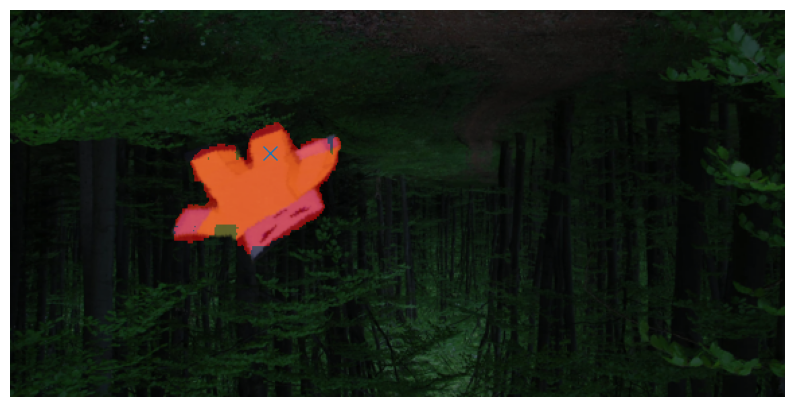

In [88]:
origimg,masked=gen.new_image(augmentation=1,char_p=0.1)
#masked=np.array(masked)
img=origimg.convert('L')
predicted=alt_predict(model,img,scale=255,thresh=0.8)
x,y=getcentroid(predicted)
disp_click(origimg,clean_segmentation_mask(predicted),x,y)

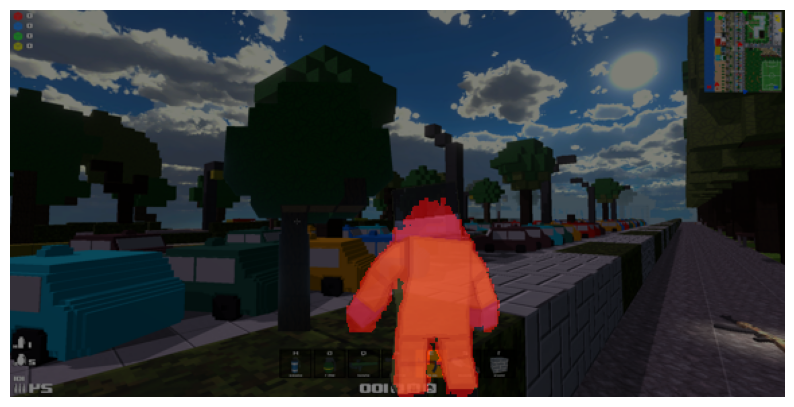

In [98]:
newmask=clean_segmentation_mask(predicted)
disp_click(origimg,newmask,x,y)

In [124]:
np.sum(predicted)/np.size(predicted)

0.0

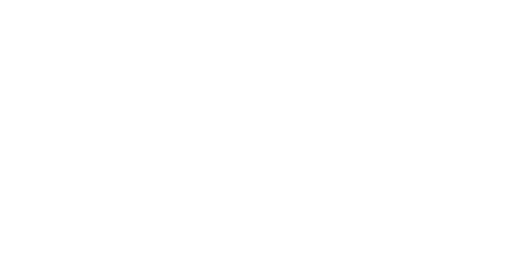

In [38]:
plt.imshow(predicted,cmap='binary')
plt.axis('off')
plt.show()

In [24]:
np.sum(predicted)

14785

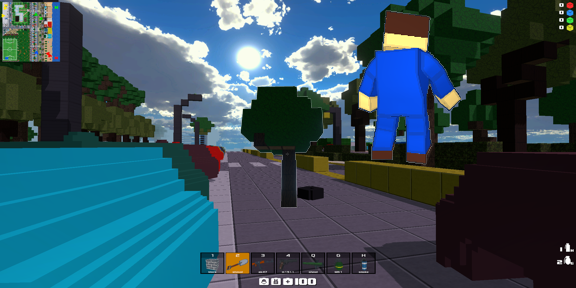

In [16]:
origimg

(-0.5, 575.5, 287.5, -0.5)

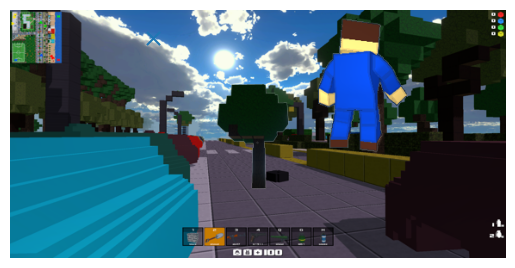

In [19]:
prova=np.array(origimg)
y=32
x=166
plt.imshow(prova)
plt.scatter(x,y,marker='x',s=90)
plt.axis('off')

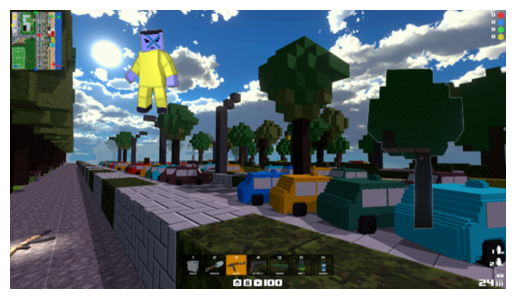

In [137]:
h,w,_=prova.shape
scalex=1920/w
scaley=1080/h
prova=Image.fromarray(prova)
prova=prova.resize((1920,1080))
prova=np.array(prova)
plt.imshow(prova)
plt.scatter(x*scalex,y*scaley,marker='x',s=90)
plt.axis('off')
plt.show()

In [132]:
h,w

(1080, 1920)

1/1 [==============================] - 0s 68ms/step


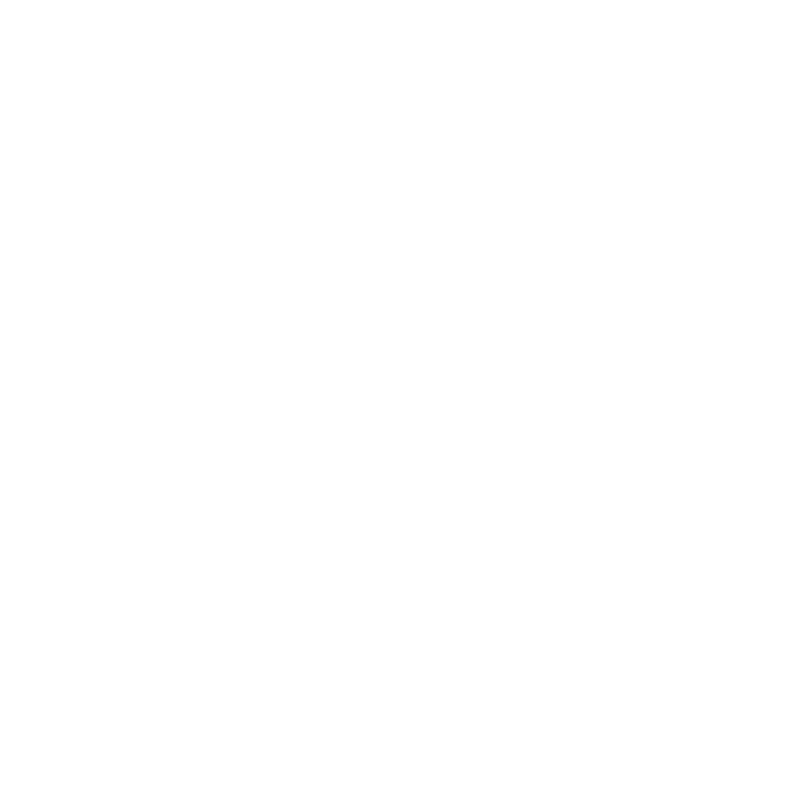

In [26]:
origimg=validset[3]
#masked=np.array(masked)
img=origimg.convert('L')
predicted=alt_predict(model,img,scale=255,thresh=0.8)
x,y=getcentroid(predicted)
disp_click(origimg,predicted,x,y)

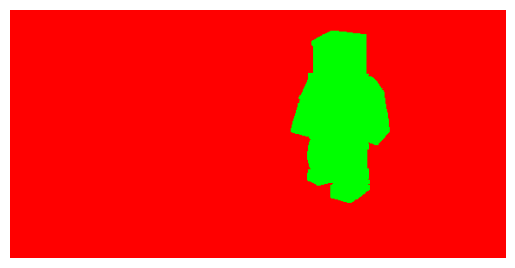

In [110]:
display_segmented(p)

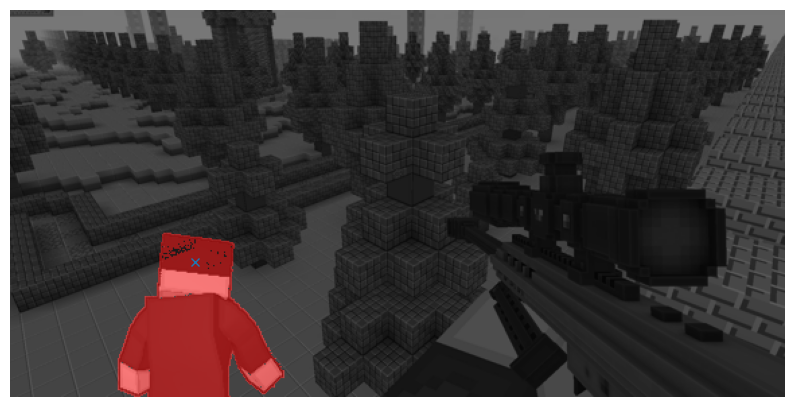

In [168]:
oldimg,p,img=make_movement(backgrounds,chars)
masked=catch_movement(oldimg,img,thresh=10)
x,y=getcentroid(masked)
disp_click(img,masked,x,y)

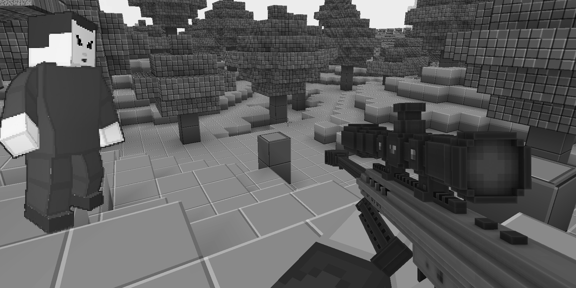

In [75]:
img

In [137]:
prova=np.column_stack(np.where(masked==1))

In [138]:
maxy,miny=np.max(prova[:,0]),np.min(prova[:,0])
h=miny+(maxy-miny)/3
prova=prova[prova[:,0]<h]
centroid=prova.mean(axis=0).astype(int)
x,y=centroid

In [139]:
maxy,miny

(233, 11)

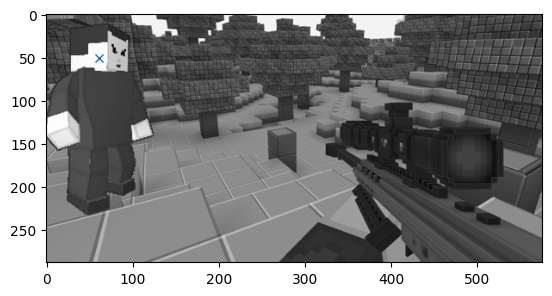

In [140]:
img=np.array(img)
plt.imshow(img,cmap='grey')
plt.plot(y,x,'x')